# Hydropower Availability: Trends & Variability Demo

This notebook is a lightweight demonstration of the JupyterHub
notebook launching environment.

It:
- Uses shared data mounted at runtime
- Runs quickly
- Produces multiple plots from the same dataset
- Highlights trends, variability, and uncertainty

### Imports

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nice
sns.set_theme(style="whitegrid")

print("Notebook environment ready.")

Notebook environment ready.


### Environment & Paths

In [2]:
# Base data directory from environment (JupyterHub mounts this)
DATA_DIR = Path(os.environ.get("DATA_DIR", "/data"))

# Keep string versions for compatibility
mpath = f"{DATA_DIR}/"
dpath = mpath + "hydrosmade_v1/"

print("mpath:", mpath)
print("dpath:", dpath)

mpath: /data/
dpath: /data/hydrosmade_v1/


### Discover Available CSV Files

In [3]:
data_path = Path(dpath)
demo_files = sorted(data_path.glob("*.csv"))

print(f"Found {len(demo_files)} CSV files")
for f in demo_files[:5]:
    print(" -", f.name)

Found 120 CSV files
 - site_level_monthly_hydro_mw_1950_2100_large_diversion_ssp126_canesm5_r1i1p1f1.csv
 - site_level_monthly_hydro_mw_1950_2100_large_diversion_ssp126_cnrm-cm6-1_r1i1p1f2.csv
 - site_level_monthly_hydro_mw_1950_2100_large_diversion_ssp126_cnrm-esm2-1_r1i1p1f2.csv
 - site_level_monthly_hydro_mw_1950_2100_large_diversion_ssp126_ec-earth3_r1i1p1f1.csv
 - site_level_monthly_hydro_mw_1950_2100_large_diversion_ssp126_gfdl-esm4_r1i1p1f1.csv


### Load One Dataset

In [4]:
if not demo_files:
    raise FileNotFoundError("No CSV files found in hydrosmade_v1")

csv_path = demo_files[0]
print("Loading:", csv_path.name)

df = pd.read_csv(csv_path)
df.head()

Loading: site_level_monthly_hydro_mw_1950_2100_large_diversion_ssp126_canesm5_r1i1p1f1.csv


,site,1950-01,1950-02,1950-03,1950-04,1950-05,1950-06,1950-07,1950-08,1950-09,...,2100-03,2100-04,2100-05,2100-06,2100-07,2100-08,2100-09,2100-10,2100-11,2100-12
0,1,0.00,0.64,0.00,42.10,0.00,121.88,126.16,127.12,123.67,...,131.92,126.57,93.53,15.21,126.16,127.12,112.99,110.63,16.02,0.00
1,20,0.00,48.44,66.80,11.22,0.00,0.00,0.00,0.00,0.00,...,16.66,1.53,0.39,0.12,0.00,0.00,0.00,0.00,0.00,0.00
2,21,86.03,135.67,135.92,136.44,54.02,63.91,133.11,135.51,133.31,...,12.57,0.53,0.00,0.00,0.00,135.51,133.31,46.46,35.67,13.97
3,24,0.00,26.82,162.63,116.33,0.00,0.00,0.00,0.00,0.00,...,101.41,35.94,3.15,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,27,77.06,133.34,98.92,44.02,17.58,9.26,2.36,0.00,0.00,...,114.86,52.56,29.90,18.96,9.34,3.21,0.00,0.00,0.00,0.00


### Quick Data Overview

In [6]:
print(f"Rows (sites): {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]:,}")

print("\nFirst 5 columns:")
print(list(df.columns[:5]))

print("\nLast 5 columns:")
print(list(df.columns[-5:]))

Rows (sites): 13,957
Total columns: 1,813

First 5 columns:
['site', '1950-01', '1950-02', '1950-03', '1950-04']

Last 5 columns:
['2100-08', '2100-09', '2100-10', '2100-11', '2100-12']


### Dataset Structure
- Each row represents a hydrologic site
- Columns represent monthly values spanning decades
- Time is encoded in column names (YYYY-MM)
- This notebook demonstrates reshaping and visualizing wide time-series data

### Time-Series Transformation

In [7]:
# Separate site column and time columns
site_col = "site"
time_cols = [c for c in df.columns if c != site_col]

# Convert wide → long format
long_df = df.melt(
    id_vars=site_col,
    value_vars=time_cols,
    var_name="month",
    value_name="value"
)

# Parse time
long_df["month"] = pd.to_datetime(long_df["month"], format="%Y-%m")

long_df.head()

,site,month,value
0,1,1950-01-01,0.00
1,20,1950-01-01,0.00
2,21,1950-01-01,86.03
3,24,1950-01-01,0.00
4,27,1950-01-01,77.06


### Plot 1: Mean Monthly Signal Across All Sites

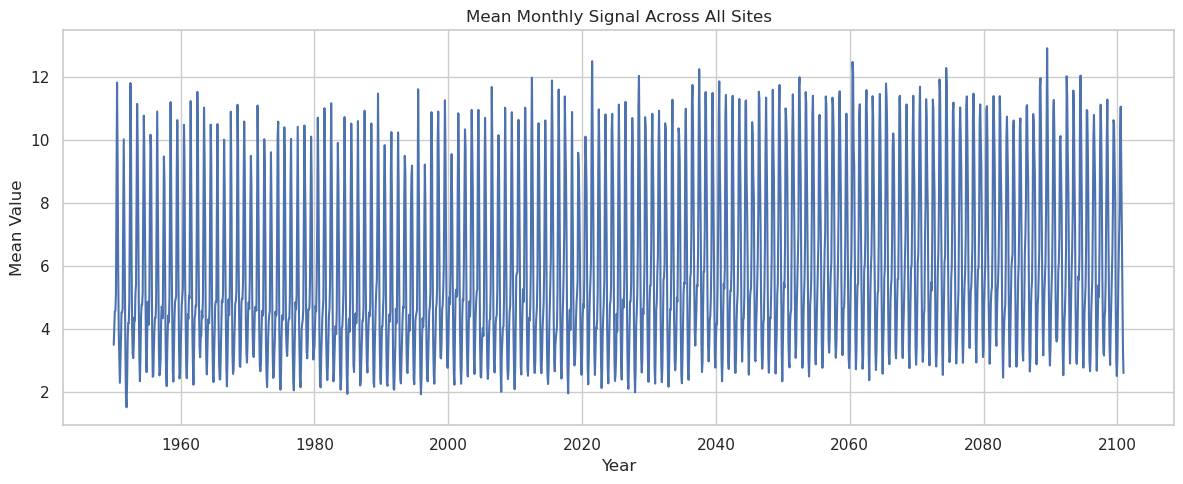

In [8]:
monthly_mean = (
    long_df
    .groupby("month", as_index=False)["value"]
    .mean()
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_mean["month"], monthly_mean["value"])

plt.title("Mean Monthly Signal Across All Sites")
plt.xlabel("Year")
plt.ylabel("Mean Value")

plt.tight_layout()
plt.show()

### Plot 2: Seasonal Cycle (Climatology)

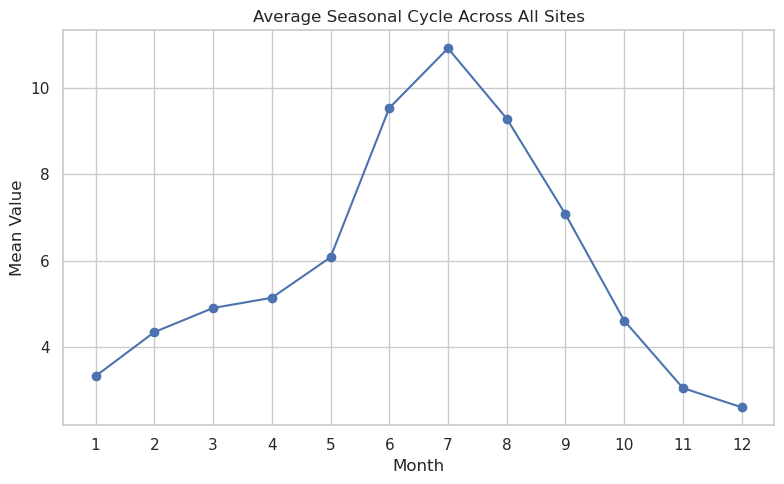

In [9]:
long_df["month_of_year"] = long_df["month"].dt.month

seasonal = (
    long_df
    .groupby("month_of_year")["value"]
    .mean()
)

plt.figure(figsize=(8, 5))
plt.plot(seasonal.index, seasonal.values, marker="o")

plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Mean Value")
plt.title("Average Seasonal Cycle Across All Sites")

plt.tight_layout()
plt.show()

### Plot 3: Compare a Few Sites

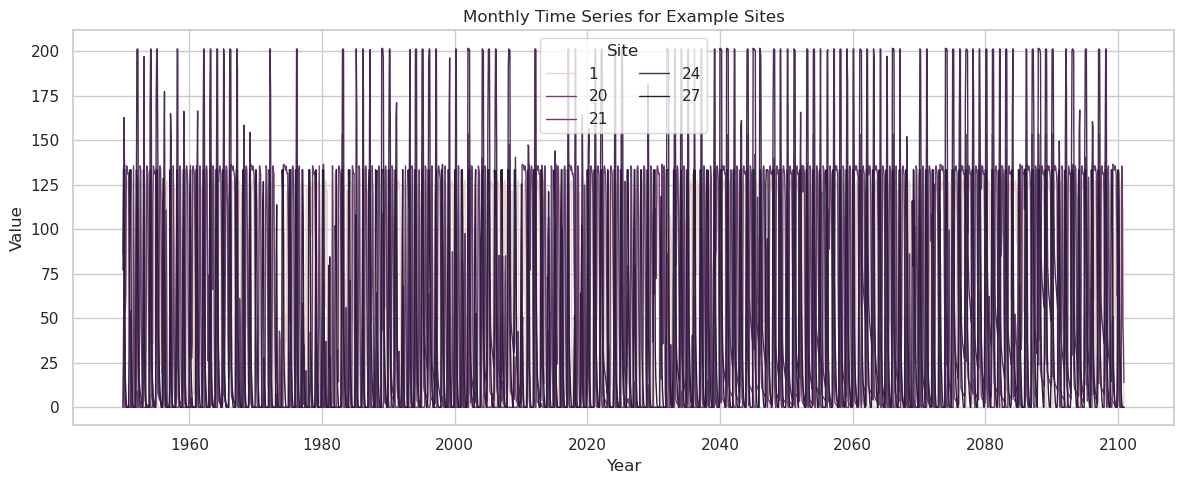

In [10]:
example_sites = df["site"].iloc[:5]

subset = long_df[long_df["site"].isin(example_sites)]

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=subset,
    x="month",
    y="value",
    hue="site",
    linewidth=1
)

plt.title("Monthly Time Series for Example Sites")
plt.xlabel("Year")
plt.ylabel("Value")

plt.legend(title="Site", ncol=2)
plt.tight_layout()
plt.show()

### Summary

In [11]:
print(
    f"""
HydrosMADE Demo Summary
----------------------
✔ Data mounted at: {dpath}
✔ Sites: {df.shape[0]:,}
✔ Monthly timesteps: {len(time_cols):,}
✔ Time span: {time_cols[0]} → {time_cols[-1]}
✔ Wide → long reshaping demonstrated
✔ Multiple plots rendered successfully
"""
)


HydrosMADE Demo Summary
----------------------
✔ Data mounted at: /data/hydrosmade_v1/
✔ Sites: 13,957
✔ Monthly timesteps: 1,812
✔ Time span: 1950-01 → 2100-12
✔ Wide → long reshaping demonstrated
✔ Multiple plots rendered successfully

